# Univariate Analysis

The objective of this notebook is to analyze each variable separately to understand its distribution, central tendencies (mean, median), and dispersion (variance, standard deviation). It also includes visualization of variables.

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
SILVER_DIR = DATA_DIR / 'silver'
DATA_FILE = SILVER_DIR / 'df_fraud.parquet'

base_directory = 'notebooks/images/images_univar_analysis'
os.makedirs(base_directory, exist_ok=True)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import pie_plot, bar_plot, bool_analysis, numerical_analysis, categorical_analysis, detect_outliers
import numpy as np
import os
from IPython.display import Image
from scipy.stats import probplot, kstest


In [3]:
df = pd.read_parquet(DATA_FILE, engine='fastparquet')
df

,step,type,amount,name_orig,old_balance_orig,new_balance_orig,name_dest,old_balance_dest,new_balance_dest,is_fraud,is_flagged_fraud
0,1,PAYMENT,9.839640e+03,C1231006815,170136.000,160296.359375,M1979787155,0.000000e+00,0.000,False,False
1,1,PAYMENT,1.864280e+03,C1666544295,21249.000,19384.720703,M2044282225,0.000000e+00,0.000,False,False
2,1,TRANSFER,1.810000e+02,C1305486145,181.000,0.000000,C553264065,0.000000e+00,0.000,True,False
3,1,CASH_OUT,1.810000e+02,C840083671,181.000,0.000000,C38997010,2.118200e+04,0.000,True,False
4,1,PAYMENT,1.166814e+04,C2048537720,41554.000,29885.859375,M1230701703,0.000000e+00,0.000,False,False
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,3.396821e+05,C786484425,339682.125,0.000000,C776919290,0.000000e+00,339682.125,True,False
6362616,743,TRANSFER,6.311410e+06,C1529008245,6311409.500,0.000000,C1881841831,0.000000e+00,0.000,True,False
6362617,743,CASH_OUT,6.311410e+06,C1162922333,6311409.500,0.000000,C1365125890,6.848884e+04,6379898.000,True,False
6362618,743,TRANSFER,8.500025e+05,C1685995037,850002.500,0.000000,C2080388513,0.000000e+00,0.000,True,False


In [4]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column            Non-Null Count    Dtype   
---  ------            --------------    -----   
 0   step              6362620 non-null  int16   
 1   type              6362620 non-null  category
 2   amount            6362620 non-null  float32 
 3   name_orig         6362620 non-null  category
 4   old_balance_orig  6362620 non-null  float32 
 5   new_balance_orig  6362620 non-null  float32 
 6   name_dest         6362620 non-null  category
 7   old_balance_dest  6362620 non-null  float32 
 8   new_balance_dest  6362620 non-null  float32 
 9   is_fraud          6362620 non-null  bool    
 10  is_flagged_fraud  6362620 non-null  bool    
dtypes: bool(2), category(3), float32(5), int16(1)
memory usage: 269.5 MB


Observations:

- No nulls

Observations:


- amount: there is an enormous variation of amount of transferred money and the standard deviation is very high (603.858). 50% of all transactions move below 74.872, 75% of all transactions move below 208.721 and the max amount is 92.445.200 so we will find very few but huge transactions (long tail).

- old_balance_orig, new_balance_orig, old_balance_dest, new_balance_dest: both have similar standard deviations and maximum values. It calls my attention that min, 25% and even 50% can be 0. That makes me wonder if those accounts have been opened or closed just to commit fraud. Some significant amount accounts have also completely completely emptied. 

- is_flagged_fraud: the mean is even lower but we have to take into consideration that this flag is activated only for transactions greater than 200.000. 

- name_orig and name_dest: some names are repeated. We will check if that has something to do with fraudulent behaviours. 

## Target (is_fraud) 

In [5]:
bool_analysis(df["is_fraud"])

Column type
bool

Unique values:
[False  True]

Total amount of unique values:
2

Descriptive statistics:
count     6362620
unique          2
top         False
freq      6354407
Name: is_fraud, dtype: object

Absolute Frequency:
is_fraud
False    6354407
True        8213
Name: count, dtype: int64

Relative Frequency (%):
is_fraud
False    99.87%
True      0.13%
Name: proportion, dtype: object

Imbalance ratio
1 : 773.70 (minority to majority)


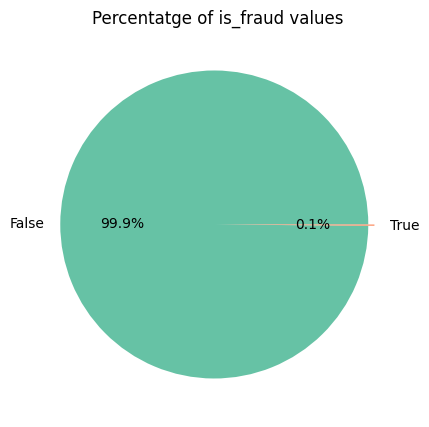

In [6]:
pie_plot(df["is_fraud"])

Observations: 

Fraudulent transactions represent only 0.13% (1 in 773 transactions), this is a severe class imbalance.

What to do: 

- Accuracy cannot be the primary metric because a naive model would classify everything as no_fraud and would get a 99.9% of accuracy. Time to check precision, recall, f-1 score, AUC-ROC, precision-recall curves

- I need to resampling or weighting like SMORE, ADASYN or class weights in model training. Also useful to check ensemble methods

- Important to use cross-validation if possible 

- Adjust thresholds

# Categorical Values

## Type

In [7]:
categorical_analysis(df["type"])

Column type
category

Unique values:
['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']

Total amount of unique values:
5

Absolute Frequency:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Relative Frequency (%):
type
CASH_OUT    35.17%
PAYMENT     33.81%
CASH_IN     21.99%
TRANSFER     8.38%
DEBIT        0.65%
Name: proportion, dtype: object


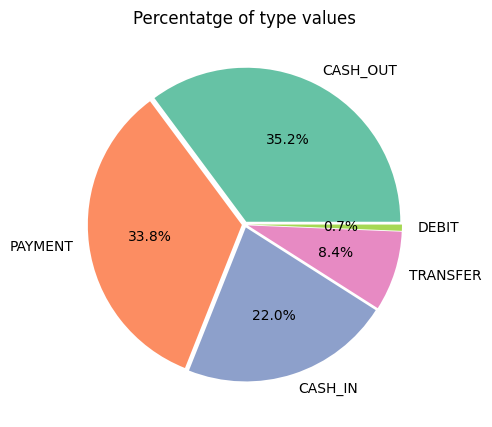

In [8]:
pie_plot(df["type"])

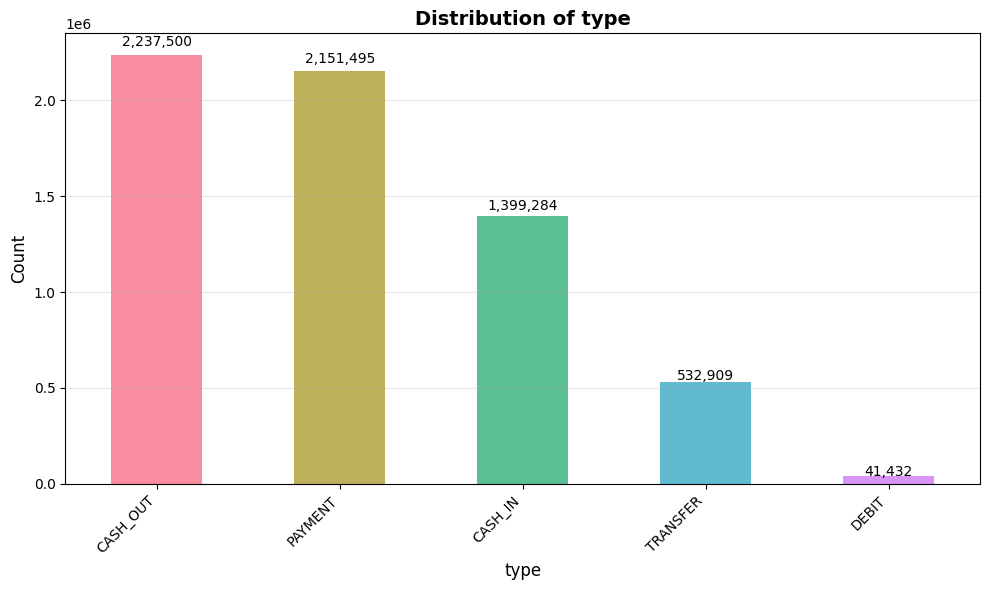

In [9]:
bar_plot(df["type"])

Observations:

- Dominant types are CASH_OUT & PAYMENT.
- DEBIT is rare (0.7%)

What to do:

- DEBIT is very rare but it still has enough rows to be considered 
- Check fraud rate per transaction type

## name_orig & name_dest

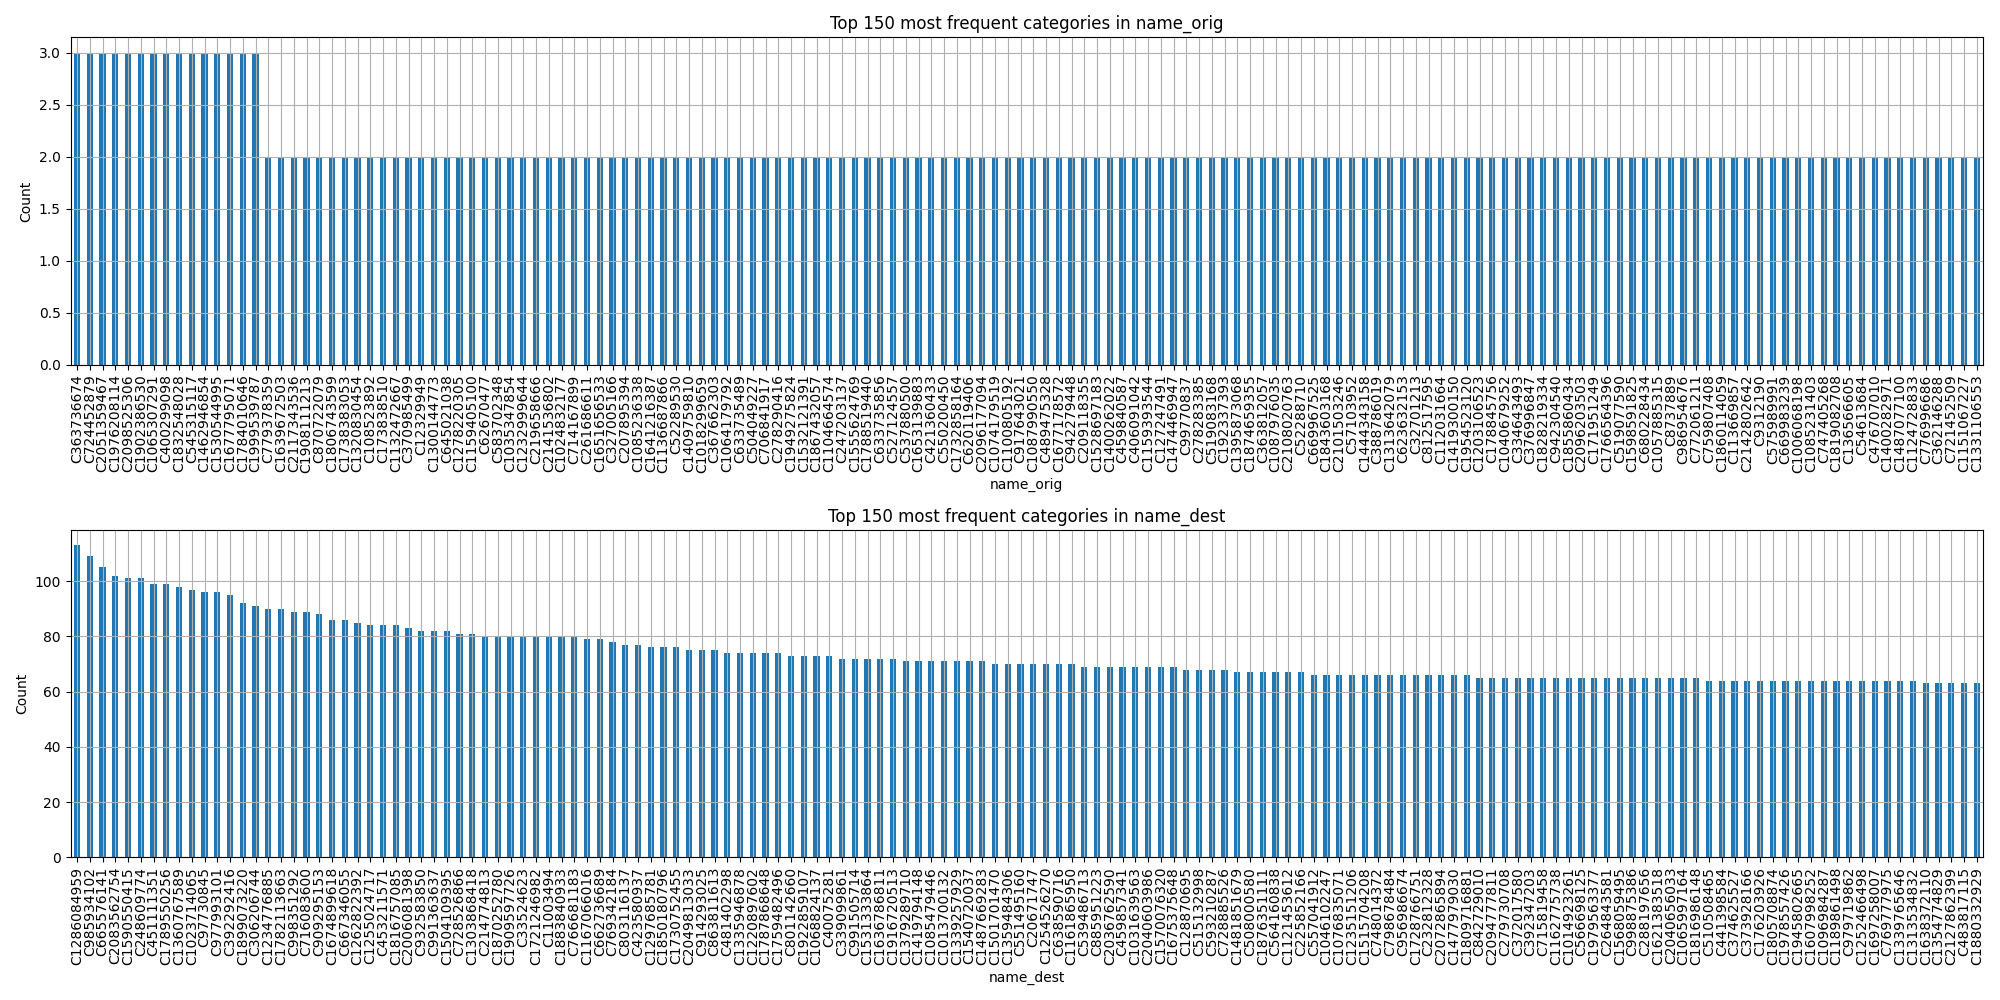

In [10]:

filename = 'barplot_nameorig_namedest.png'
plot_filename = os.path.join(base_directory, filename)
    
if not os.path.isfile(plot_filename):
    categorical_cols = [ 'name_orig', 'name_dest']

    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 10))

    for ax, col in zip(axs, categorical_cols):
        top_categories = df[col].value_counts().nlargest(150)
        
        top_categories.plot(kind='bar', ax=ax)
        
        ax.set_title(f'Top 150 most frequent categories in {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.grid(True)

    plt.tight_layout()
    plt.savefig(plot_filename)  
    plt.close(fig)  

Image(filename=plot_filename)

Observations:
- name_orig: some accounts have sent money 2-3 times (low repeat senders)
- name_dest: High-frequency receivers exist (> 100 transactions/account).

What to do:

- Engineer feats: high cardinality, transaction frequency per account
- Analyse fraud rate vs. account activity level

# Numerical variables

### Step

In [11]:
numerical_analysis(df['step'])

Column type
int16

Missing values:
0

Descriptive statistics:
count    6.362620e+06
mean     2.433972e+02
std      1.423320e+02
min      1.000000e+00
25%      1.560000e+02
50%      2.390000e+02
75%      3.350000e+02
max      7.430000e+02
Name: step, dtype: float64

Measures of central tendency
Median: 239.0
Mode: 19

Measures of dispersion
\Q1: 156.0
Q3: 335.0
IQR: 179.0
Lower fence: -112.5
Upper fence: 603.5
Number of potential outliers: 102688

Skewness and Kurtosis:
Skewness: 0.38
Kurtosis: 0.33


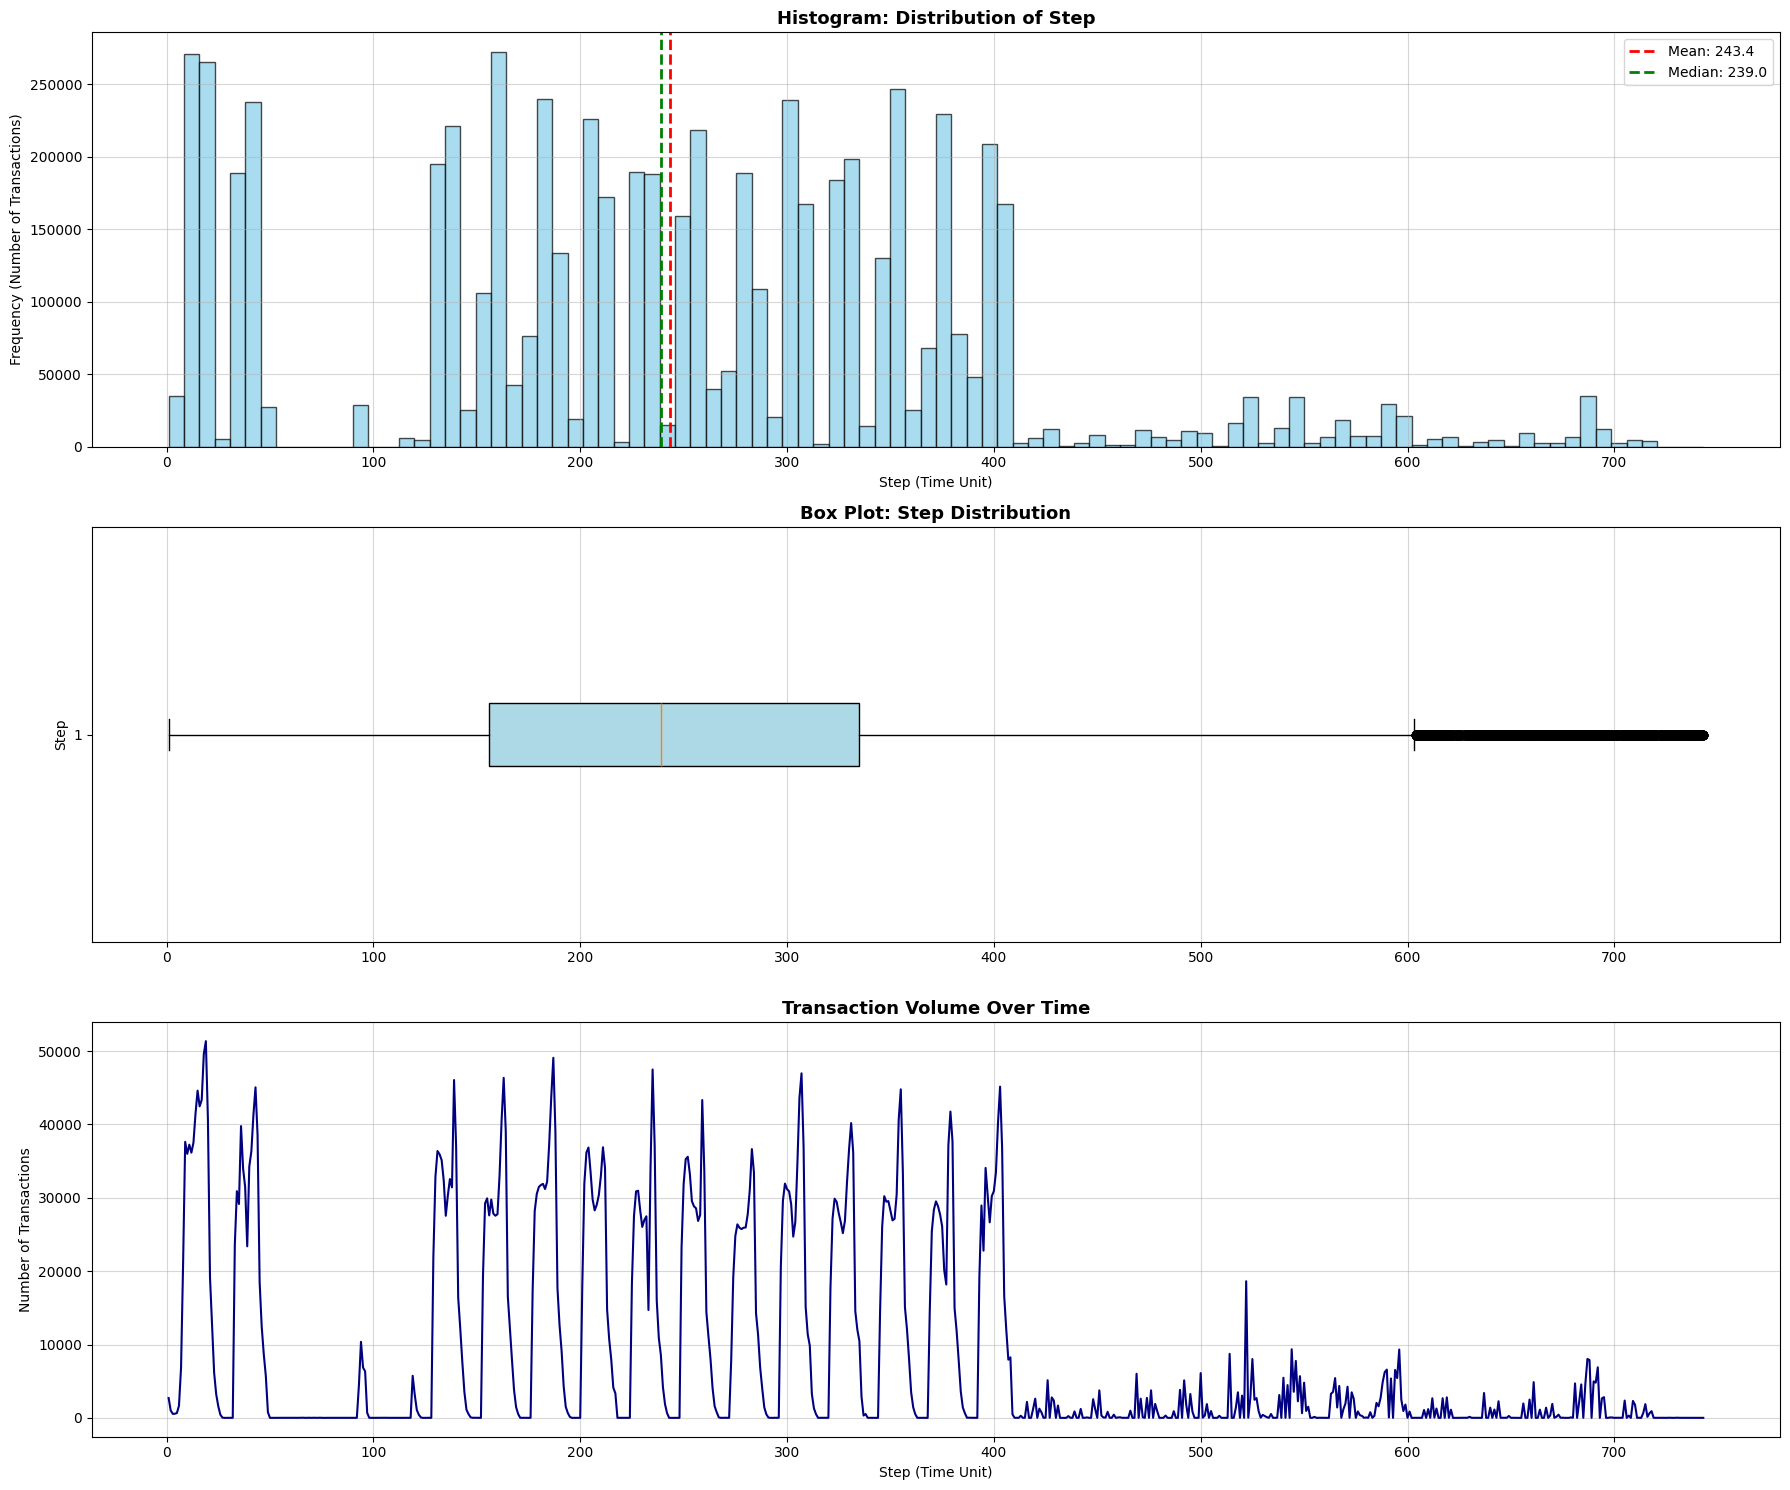

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15))

# Histogram
axes[0].hist(df['step'], bins=100, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title('Histogram: Distribution of Step', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Step (Time Unit)')
axes[0].set_ylabel('Frequency (Number of Transactions)')
axes[0].axvline(df['step'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["step"].mean():.1f}')
axes[0].axvline(df['step'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["step"].median():.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.5)

# Box plot
bp = axes[1].boxplot(df['step'], vert=False, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[1].set_title('Box Plot: Step Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Step')
axes[1].grid(True, alpha=0.5, axis='x')

# Fraud frequency over time
transactions_per_step = df.groupby('step').size()
axes[2].plot(transactions_per_step.index, transactions_per_step.values, color='navy', linewidth=1.5)
axes[2].set_title('Transaction Volume Over Time', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Step (Time Unit)')
axes[2].set_ylabel('Number of Transactions')
axes[2].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

Observations: 

- The histogram shows a roughly uniform distribution with a slight right skew (skewness=0.375)
- No major gaps or missing time periods visible
- Mean (243.4) is slightly higher than median (239.0), confirming the rightskew
- Data spans 743 unique time steps (1 to 743), suggesting ~31 days if steps are hours
- Some steps have higher transaction volumes than others, this could reflect daily/weekly patterns
- Box plot shows extreme outliers in time values indicating few transactions spread across the later time range. These outliers are expected and should be kept, as they reflect real activity patterns

Next steps:
1. In bivariate analysis: Check if certain time periods correlate with different patterns
2. Consider creating cyclical features (e.g., time_of_day, day_of_week) if step represents hours
3. May bin into time windows for pattern analysis
4. Investigate the volume fluctuations to understand if they follow a pattern
